In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install kmodes

In [3]:
import numpy as np
import pandas as pd
from sklearn import metrics, preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from kmodes.kmodes import KModes
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
file_path = '/content/drive/My Drive/cardio_train.csv'
df = pd.read_csv(file_path, sep=';', encoding='utf-8')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
print(df.isnull().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [6]:
#drop id
df = df.drop('id', axis=1)


 Converting age from days to years

In [7]:
df['age'] = (df['age'] / 365).round().astype('int')


Attribute Combination

It is important to combine some attributes into more meaningful ones. For example, using Body Mass Index (BMI) instead of the features weight and height individually, is more useful. Therefore, we have added Body Mass Index (BMI) and Mean Arterial Pressure (MAP) to the data.

In [8]:
df = df[
    (df['height'] > 100) & (df['height'] < 250) &
    (df['weight'] > 30) &
    (df['ap_hi'] > 0) &
    (df['ap_lo'] > 0) &
    (df['ap_hi'] >= df['ap_lo'])
]


In [9]:
df['height_raw'] = df['height']
df['weight_raw'] = df['weight']
df['ap_hi_raw']  = df['ap_hi']
df['ap_lo_raw']  = df['ap_lo']

# 2. Compute BMI from raw values
df['bmi_raw'] = df['weight_raw'] / ((df['height_raw'] / 100) ** 2)



In [10]:
df['bmi'] = pd.qcut(
    df['bmi_raw'],
    q=6,
    duplicates='drop'
)

df['bmi'] = df['bmi'].cat.codes



In [11]:
df['map_raw'] = ((2 * df['ap_lo_raw']) + df['ap_hi_raw']) / 3



In [12]:
df['map'] = pd.qcut(
    df['map_raw'],
    q=6,
    duplicates='drop'
)

df['map'] = df['map'].cat.codes



In [13]:
df['map'].value_counts().sort_index()
df['bmi'].value_counts().sort_index()


,count
bmi,
0,11509
1,11393
2,11523
3,11383
4,11454
5,11442


In [14]:
df['age_group'] = pd.cut(
    df['age'],
    bins=7,
    labels=range(7),
    include_lowest=True
).astype(int)



Drop features We only need categorical data

In [15]:
df = df.drop(columns=[
    'height', 'weight',
    'ap_hi', 'ap_lo',
    'height_raw', 'weight_raw',
    'ap_hi_raw', 'ap_lo_raw',
    'bmi_raw', 'map_raw',
    'age'
])



In [ ]:

df.head()


,gender,cholesterol,gluc,smoke,alco,active,cardio,bmi,map,age_group
0,2,1,1,0,0,1,0,0,1,3
1,1,3,1,0,0,1,1,5,3,4
2,1,3,1,0,0,0,1,1,1,4
3,2,1,1,0,0,1,1,4,4,3
4,1,1,1,0,0,0,0,0,0,3


# Train Test split

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['cardio'])
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



# Outliers handling

We removed rows from the training data that fall outside the 2.5–97.5% range for any feature, ensuring X and y remain aligned.

In [17]:
outlier_cols = X_train.columns

bounds = {}
for col in outlier_cols:
    bounds[col] = (
        X_train[col].quantile(0.025),
        X_train[col].quantile(0.975)
    )

for col, (low, high) in bounds.items():
    X_train = X_train[
        (X_train[col] >= low) & (X_train[col] <= high)
    ]
    y_train = y_train.loc[X_train.index]



In [ ]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("Train class balance:")
print(y_train.value_counts(normalize=True))

print("Test class balance:")
print(y_test.value_counts(normalize=True))


Train shape: (54960, 9) (54960,)
Test shape: (13741, 9) (13741,)
Train class balance:
cardio
0    0.505113
1    0.494887
Name: proportion, dtype: float64
Test class balance:
cardio
0    0.505131
1    0.494869
Name: proportion, dtype: float64


In [ ]:
print("Train null rows:", X_train.isnull().any(axis=1).sum())
print("Test null rows:", X_test.isnull().any(axis=1).sum())


Train null rows: 0
Test null rows: 0


In [ ]:
X_train.dtypes


,0
gender,int64
cholesterol,int64
gluc,int64
smoke,int64
alco,int64
active,int64
bmi,int8
map,int8
age_group,int64


**Clustering**


Clustering is used in machine learning to find similarities between data by grouping. The most common technique for clustering is K-means. However, it is not effective for categorical data. K-means uses a Euclidean distance measure differences between data points. For our data, we have used K-modes which is the appropriate clustering algorithm for categorical data because it uses mode-based distance between the categories, so it is more suitable for categorical data. To find the optimal number of clusters, we have utilized the elbow curve method.

In [18]:
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

cost = []
num_clusters = range(1, 6)

for k in num_clusters:
    km = KModes(
        n_clusters=k,
        init='Huang',
        n_init=5,
        verbose=0,
        random_state=1
    )
    km.fit(X_train)   # 🔒 TRAIN ONLY
    cost.append(km.cost_)



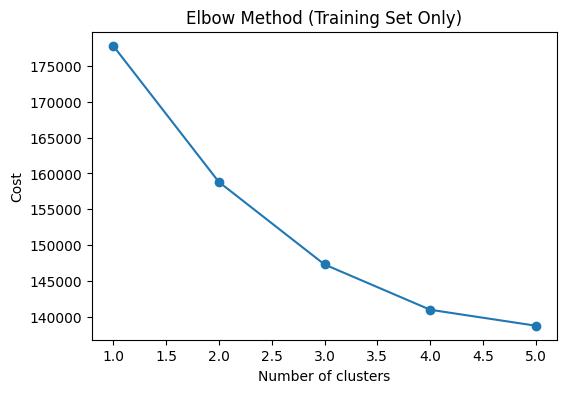

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(num_clusters, cost, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method (Training Set Only)')
plt.show()


Building KModes model

In [20]:
km = KModes(
    n_clusters=2,
    init='Huang',
    n_init=5,
    random_state=1
)

train_clusters = km.fit_predict(X_train)
test_clusters  = km.predict(X_test)

X_train.insert(0, 'clusters', train_clusters)
X_test.insert(0, 'clusters', test_clusters)


In [21]:
print(X_train.shape, X_test.shape)
print(X_train.columns)

print(X_train['clusters'].value_counts(normalize=True))
print(X_test['clusters'].value_counts(normalize=True))


(54960, 10) (13741, 10)
Index(['clusters', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active',
       'bmi', 'map', 'age_group'],
      dtype='object')
clusters
0    0.717576
1    0.282424
Name: proportion, dtype: float64
clusters
0    0.720835
1    0.279165
Name: proportion, dtype: float64


In [22]:
X_train.head()


,clusters,gender,cholesterol,gluc,smoke,alco,active,bmi,map,age_group
46667,0,1,1,1,0,0,1,3,0,2
64019,1,2,3,3,0,0,1,3,4,5
33878,1,2,1,1,0,0,1,4,0,5
22448,0,1,1,1,0,0,1,0,0,3
67731,0,1,1,1,0,0,1,0,0,4


# **Models Implementation**

**Stacking model**

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# -----------------------------
# Base learners (unchanged)
# -----------------------------
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('et', ExtraTreesClassifier(
        n_estimators=550,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('dt', DecisionTreeClassifier(
        max_depth=7,
        random_state=42
    ))
]

# -----------------------------
# Meta-learner (unchanged)
# -----------------------------
lr_model = LogisticRegression(
    C=100,
    max_iter=1000,
    penalty='l2',
    solver='liblinear',
    random_state=42
)

# -----------------------------
# Cross-validation strategy
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# Stacking classifier
# -----------------------------
stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=lr_model,
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

# -----------------------------
# Train
# -----------------------------
stacking_classifier.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred = stacking_classifier.predict(X_train)
y_test_pred  = stacking_classifier.predict(X_test)

y_test_prob = stacking_classifier.predict_proba(X_test)[:, 1]

# -----------------------------
# Evaluation
# -----------------------------
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.6f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.6f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_prob):.6f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 0.732751
Test Accuracy: 0.714795
Test ROC-AUC: 0.783218

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.73      6941
           1       0.73      0.68      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.72      0.71      0.71     13741
weighted avg       0.72      0.71      0.71     13741



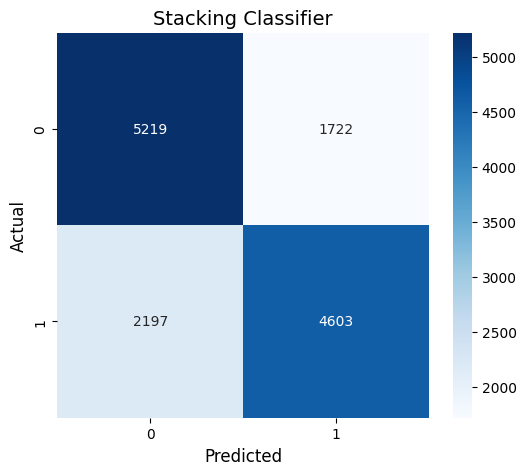

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix

cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Stacking Classifier', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()




Stacking classifier with seed value 0, 7, 123 and 2024

In [ ]:
import pandas as pd
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold


seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    # -----------------------------
    # Base learners (seed applied)
    # -----------------------------
    base_models = [
        ('rf', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=seed,
            n_jobs=-1
        )),
        ('et', ExtraTreesClassifier(
            n_estimators=550,
            max_depth=None,
            random_state=seed,
            n_jobs=-1
        )),
        ('dt', DecisionTreeClassifier(
            max_depth=7,
            random_state=seed
        ))
    ]

    # -----------------------------
    # Meta-learner
    # -----------------------------
    lr_model = LogisticRegression(
        C=100,
        max_iter=1000,
        penalty='l2',
        solver='liblinear',
        random_state=seed
    )

    # -----------------------------
    # CV strategy (same as original)
    # -----------------------------
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    # -----------------------------
    # Stacking classifier
    # -----------------------------
    stacking_classifier = StackingClassifier(
        estimators=base_models,
        final_estimator=lr_model,
        cv=cv,
        n_jobs=-1,
        passthrough=False
    )

    # -----------------------------
    # Train (FIXED train set)
    # -----------------------------
    stacking_classifier.fit(X_train, y_train)

    # -----------------------------
    # Test evaluation (FIXED test set)
    # -----------------------------
    y_pred = stacking_classifier.predict(X_test)
    y_prob = stacking_classifier.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    results.append([seed, acc, prec, rec, f1, auc])


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_stack = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
)

pd.set_option('display.precision', 10)
print(df_stack)

print("\nSummary Statistics:")
print(df_stack.describe())


   Seed      Accuracy     Precision        Recall            F1       ROC_AUC
0     0  0.7152317881  0.7282935316  0.6772058824  0.7018212299  0.7833002534
1     7  0.7149406885  0.7282660333  0.6763235294  0.7013343500  0.7832153784
2   123  0.7150134634  0.7275883838  0.6779411765  0.7018879415  0.7832176454
3  2024  0.7147951386  0.7273157646  0.6777941176  0.7016822714  0.7833816326

Summary Statistics:
                  Seed      Accuracy     Precision        Recall  \
count     4.0000000000  4.0000000000  4.0000000000  4.0000000000   
mean    538.5000000000  0.7149952696  0.7278659283  0.6773161765   
std     991.9383381373  0.0001819373  0.0004907951  0.0007340676   
min       0.0000000000  0.7147951386  0.7273157646  0.6763235294   
25%       5.2500000000  0.7149043010  0.7275202290  0.6769852941   
50%      65.0000000000  0.7149770759  0.7279272085  0.6775000000   
75%     598.2500000000  0.7150680445  0.7282729078  0.6778308824   
max    2024.0000000000  0.7152317881  0.72829

**Simple feedforward neural networks**

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

x_train = X_train.values
x_test  = X_test.values

y_train_cat = to_categorical(y_train)
y_test_cat  = to_categorical(y_test)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_simple = Sequential([
    Dense(64, input_shape=(x_train.shape[1],), activation="relu"),
    Dense(32, activation="relu"),
    Dense(2, activation="softmax")   # 2 output neurons for binary class
])

model_simple.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model_simple.fit(
    x_train, y_train_cat,
    epochs=32,
    batch_size=32,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

# ------------------------------------------------------
# Training accuracy
# ------------------------------------------------------
train_loss, train_acc = model_simple.evaluate(
    x_train, y_train_cat, verbose=0
)

# ------------------------------------------------------
# Test accuracy
# ------------------------------------------------------
test_loss, test_acc = model_simple.evaluate(
    x_test, y_test_cat, verbose=0
)

print(f"Training Accuracy: {train_acc:.6f}")
print(f"Test Accuracy:     {test_acc:.6f}")

from sklearn.metrics import classification_report

# ------------------------------------------------------
# Predictions
# ------------------------------------------------------
y_test_prob = model_simple.predict(x_test)
y_test_pred = np.argmax(y_test_prob, axis=1)

# ------------------------------------------------------
# Classification report
# ------------------------------------------------------
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))



Epoch 1/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6932 - loss: 0.5939 - val_accuracy: 0.7105 - val_loss: 0.5726
Epoch 2/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7186 - loss: 0.5633 - val_accuracy: 0.7140 - val_loss: 0.5637
Epoch 3/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7211 - loss: 0.5585 - val_accuracy: 0.7115 - val_loss: 0.5644
Epoch 4/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7201 - loss: 0.5611 - val_accuracy: 0.7136 - val_loss: 0.5606
Epoch 5/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7258 - loss: 0.5544 - val_accuracy: 0.7155 - val_loss: 0.5684
Epoch 6/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7215 - loss: 0.5592 - val_accuracy: 0.7195 - val_loss: 0.5604
Epoch 7/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7229 - loss: 0.5543 - val_accuracy: 0.7175 - val_loss: 0.5610
Epoch 8/32
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7249 - loss: 0.5555 - 

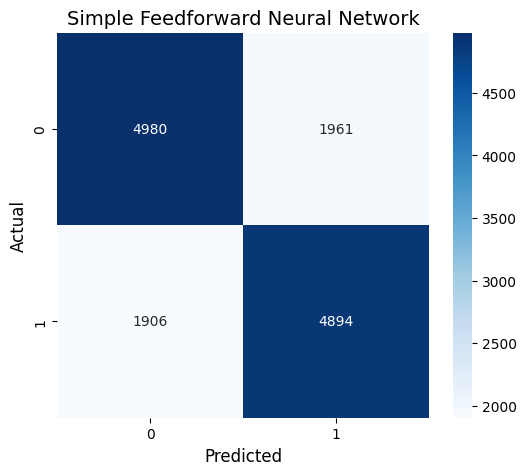

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Simple Feedforward Neural Network', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


Training Loss: 0.5515064001083374
Training Accuracy: 0.7259825468063354
Test Loss: 0.5606070160865784
Test Accuracy: 0.7185794115066528


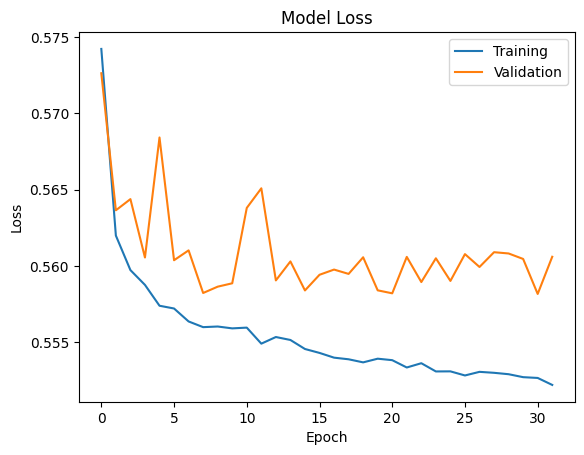

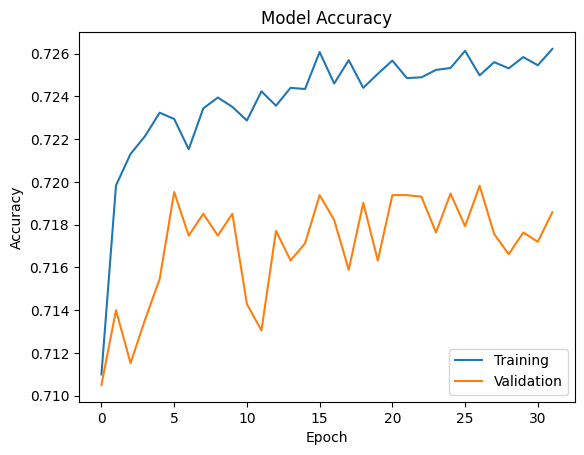

In [ ]:
# ------------------------------------------------------
# Evaluate the model on TRAIN set
# ------------------------------------------------------
train_loss, train_acc = model_simple.evaluate(
    x_train, y_train_cat, verbose=0
)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_acc)


# ------------------------------------------------------
# Evaluate the model on TEST set
# ------------------------------------------------------
test_loss, test_acc = model_simple.evaluate(
    x_test, y_test_cat, verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Plot training vs validation loss
# ------------------------------------------------------
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

# ------------------------------------------------------
# Plot training vs validation accuracy
# ------------------------------------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()


Simple Feedforward Neural Network with 0, 7, 123 and 2024 seed value



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------------------
# Fixed data
# ------------------------------------------------------
x_train = X_train.values
x_test  = X_test.values

y_train_cat = to_categorical(y_train)
y_test_cat  = to_categorical(y_test)

# ------------------------------------------------------
# Seeds (model randomness only)
# ------------------------------------------------------
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    print(f"\n==============================")
    print(f" Training NN with seed = {seed}")
    print(f"==============================")

    # -----------------------------
    # Set seeds
    # -----------------------------
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # -----------------------------
    # Model (unchanged)
    # -----------------------------
    model_simple = Sequential([
        Dense(64, input_shape=(x_train.shape[1],), activation="relu"),
        Dense(32, activation="relu"),
        Dense(2, activation="softmax")
    ])

    model_simple.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # -----------------------------
    # Train
    # -----------------------------
    history = model_simple.fit(
        x_train, y_train_cat,
        epochs=32,
        batch_size=32,
        validation_data=(x_test, y_test_cat),
        verbose=0
    )

    # -----------------------------
    # Predictions (TEST)
    # -----------------------------
    y_test_prob = model_simple.predict(x_test, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    # -----------------------------
    # Metrics (same as before)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    # -----------------------------
    # Classification report
    # -----------------------------
    print(f"\nSeed {seed} – Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_nn = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\nNeural Network – Seed Sensitivity Results")
print(df_nn)

print("\nSummary Statistics:")
print(df_nn.describe())



 Training NN with seed = 0

Seed 0 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.72      0.74      0.73      6941
           1       0.72      0.70      0.71      6800

    accuracy                           0.72     13741
   macro avg       0.72      0.72      0.72     13741
weighted avg       0.72      0.72      0.72     13741


 Training NN with seed = 7

Seed 7 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      6941
           1       0.75      0.63      0.69      6800

    accuracy                           0.72     13741
   macro avg       0.72      0.71      0.71     13741
weighted avg       0.72      0.72      0.71     13741


 Training NN with seed = 123

Seed 123 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.79      0.74      6941
           1     

**CNN**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

X_tr = X_tr.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

X_tr_cnn  = X_tr.values.reshape(X_tr.shape[0], X_tr.shape[1], 1)
X_val_cnn = X_val.values.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

model_cnn = Sequential()

model_cnn.add(Conv1D(64, kernel_size=2, activation='relu',
                     input_shape=(X_tr_cnn.shape[1], 1)))
model_cnn.add(MaxPooling1D(pool_size=2))

model_cnn.add(Conv1D(128, kernel_size=2, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))

model_cnn.add(Flatten())
model_cnn.add(Dense(256, activation='relu'))
model_cnn.add(Dropout(0.1))
model_cnn.add(Dense(1, activation='sigmoid'))

model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_tr_cnn, y_tr,
    epochs=32,
    batch_size=128,
    validation_data=(X_val_cnn, y_val),
    verbose=1
)

test_loss, test_acc = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.6f}")


from sklearn.metrics import classification_report

# ------------------------------------------------------
# Predictions (probabilities)
# ------------------------------------------------------
y_test_prob = model_cnn.predict(X_test_cnn, verbose=0)

# ------------------------------------------------------
# Convert probabilities → class labels
# ------------------------------------------------------
y_test_pred = (y_test_prob >= 0.5).astype(int).ravel()

# ------------------------------------------------------
# Classification report
# ------------------------------------------------------
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Epoch 1/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5535 - loss: 0.6831 - val_accuracy: 0.5882 - val_loss: 0.6657
Epoch 2/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5911 - loss: 0.6671 - val_accuracy: 0.5866 - val_loss: 0.6639
Epoch 3/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5910 - loss: 0.6665 - val_accuracy: 0.5978 - val_loss: 0.6635
Epoch 4/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5934 - loss: 0.6662 - val_accuracy: 0.5980 - val_loss: 0.6632
Epoch 5/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5921 - loss: 0.6661 - val_accuracy: 0.5979 - val_loss: 0.6631
Epoch 6/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5919 - loss: 0.6659 - val_accuracy: 0.5979 - val_loss: 0.6629
Epoch 7/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5928 - loss: 0.6656 - val_accuracy: 0.5979 - val_loss: 0.6629
Epoch 8/32
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5926 - loss: 0.6654 - val_accuracy:

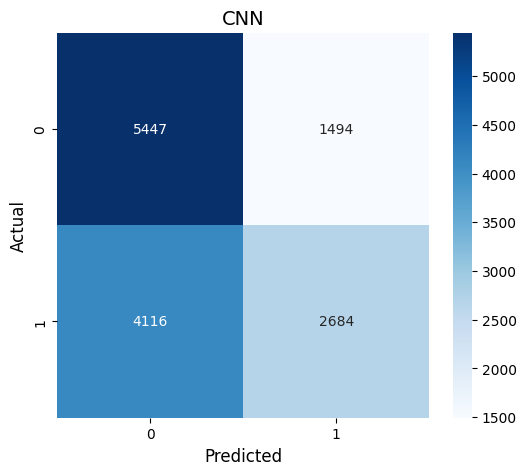

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('CNN', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


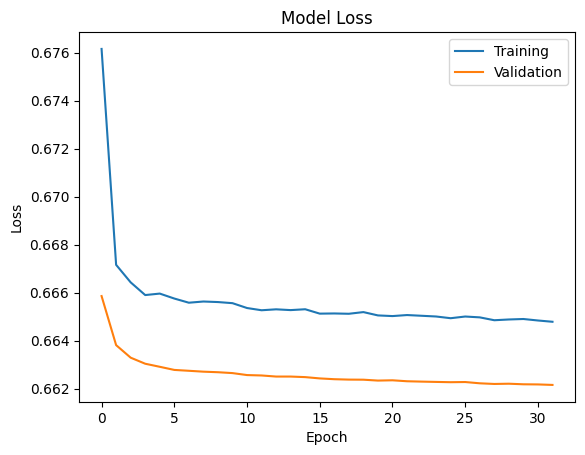

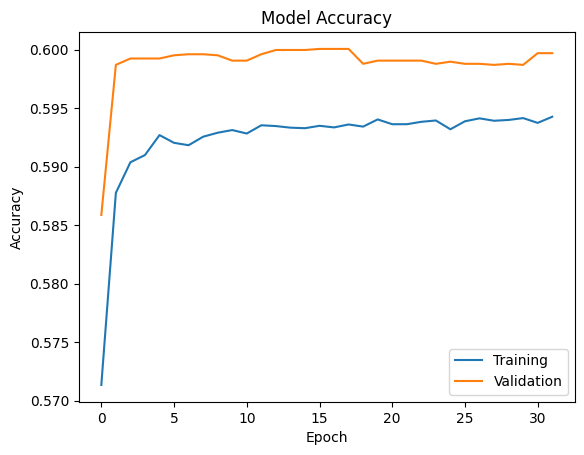

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Plot training vs validation loss
# ------------------------------------------------------
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()
 # ------------------------------------------------------
# Plot training vs validation accuracy
# ------------------------------------------------------
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()


CNN model with 0, 7, 123 and 2024 seed value

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------
# Data already prepared (fixed)
# X_tr_cnn, X_val_cnn, X_test_cnn
# y_tr, y_val, y_test
# ------------------------------------------------------

seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training CNN with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Set seeds
    # -----------------------------
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # -----------------------------
    # CNN model (UNCHANGED)
    # -----------------------------
    model_cnn = Sequential()

    model_cnn.add(Conv1D(
        64, kernel_size=2, activation='relu',
        input_shape=(X_tr_cnn.shape[1], 1)
    ))
    model_cnn.add(MaxPooling1D(pool_size=2))

    model_cnn.add(Conv1D(128, kernel_size=2, activation='relu'))
    model_cnn.add(MaxPooling1D(pool_size=2))

    model_cnn.add(Flatten())
    model_cnn.add(Dense(256, activation='relu'))
    model_cnn.add(Dropout(0.1))
    model_cnn.add(Dense(1, activation='sigmoid'))

    model_cnn.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # -----------------------------
    # Train
    # -----------------------------
    history_cnn = model_cnn.fit(
        X_tr_cnn, y_tr,
        epochs=32,
        batch_size=128,
        validation_data=(X_val_cnn, y_val),
        verbose=0
    )

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_prob = model_cnn.predict(X_test_cnn, verbose=0)
    y_test_pred = (y_test_prob >= 0.5).astype(int).ravel()

    # -----------------------------
    # Metrics (same as before)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    # -----------------------------
    # Classification report
    # -----------------------------
    print(f"\nSeed {seed} – Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_cnn = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\nCNN – Seed Stability Results")
print(df_cnn)

print("\nSummary Statistics:")
print(df_cnn.describe())



 Training CNN with seed = 0

Seed 0 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.57      0.78      0.66      6941
           1       0.64      0.40      0.49      6800

    accuracy                           0.59     13741
   macro avg       0.60      0.59      0.58     13741
weighted avg       0.60      0.59      0.58     13741


 Training CNN with seed = 7

Seed 7 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.57      0.79      0.66      6941
           1       0.64      0.39      0.49      6800

    accuracy                           0.59     13741
   macro avg       0.61      0.59      0.57     13741
weighted avg       0.61      0.59      0.58     13741


 Training CNN with seed = 123

Seed 123 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.57      0.78      0.66      6941
           1  

**Decision Trees**

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Test Accuracy: 0.714286

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.70      0.75      0.73      6941
           1       0.73      0.68      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.72      0.71      0.71     13741
weighted avg       0.72      0.71      0.71     13741



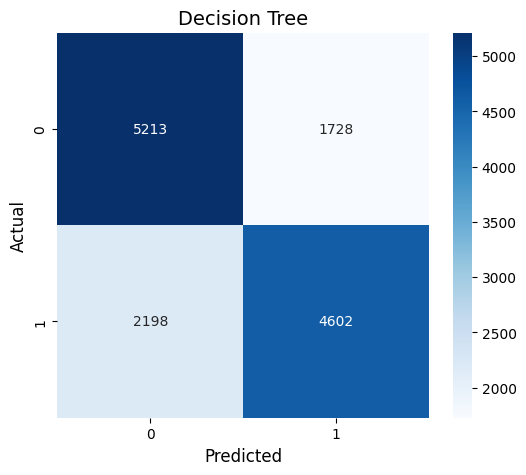

In [ ]:
# ======================================================
# Decision Tree with GridSearchCV
# ======================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------
# Parameter grid (SAME as before)
# ------------------------------------------------------
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# ------------------------------------------------------
# Base Decision Tree model (SAME settings)
# ------------------------------------------------------
dt = DecisionTreeClassifier(random_state=42)

# ------------------------------------------------------
# GridSearchCV (5-fold CV on TRAINING SET ONLY)
# ------------------------------------------------------
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# ------------------------------------------------------
# Fit on training data ONLY (no leakage)
# ------------------------------------------------------
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# ------------------------------------------------------
# Final evaluation on TEST set
# ------------------------------------------------------
y_test_pred = best_dt.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.6f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Decision Tree', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


Decision Tree with seed value 0, 7, 123 and 2024

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------------------
# Parameter grid (SAME as before)
# ------------------------------------------------------
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# ------------------------------------------------------
# Seeds for robustness analysis
# ------------------------------------------------------
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    print("\n===================================")
    print(f" Decision Tree GridSearch — Seed {seed}")
    print("===================================")

    # --------------------------------------------------
    # Base Decision Tree (seed applied)
    # --------------------------------------------------
    dt = DecisionTreeClassifier(random_state=seed)

    # --------------------------------------------------
    # GridSearchCV (5-fold CV on TRAIN ONLY)
    # --------------------------------------------------
    grid_search = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # --------------------------------------------------
    # Fit on TRAINING data only
    # --------------------------------------------------
    grid_search.fit(X_train, y_train)

    best_dt = grid_search.best_estimator_
    print(f"Best Parameters (Seed {seed}): {grid_search.best_params_}")

    # --------------------------------------------------
    # Final evaluation on TEST set
    # --------------------------------------------------
    y_test_pred = best_dt.predict(X_test)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_dt = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\nDecision Tree (GridSearchCV) – Seed Stability Results")
print(df_dt)

print("\nSummary Statistics:")
print(df_dt.describe())



 Decision Tree GridSearch — Seed 0
Best Parameters (Seed 0): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Seed 0 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.73      6941
           1       0.73      0.68      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.72      0.71      0.71     13741
weighted avg       0.72      0.71      0.71     13741


 Decision Tree GridSearch — Seed 7
Best Parameters (Seed 7): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Seed 7 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.73      6941
           1       0.73      0.68      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.72      0.71      0.71     13741
weighted avg       

**Random Forest**

In [27]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ------------------------------------------------------
# Data already prepared (FIXED – no re-splitting)
# X_train, X_test
# y_train, y_test
# ------------------------------------------------------

seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training Random Forest with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Set seed (model randomness only)
    # -----------------------------
    np.random.seed(seed)

    # -----------------------------
    # Random Forest model (UNCHANGED)
    # -----------------------------
    rf_model = RandomForestClassifier(
        n_estimators=100,
        min_impurity_decrease=0.01,
        bootstrap=True,
        random_state=seed,
        class_weight='balanced'
    )

    # -----------------------------
    # Train
    # -----------------------------
    rf_model.fit(X_train, y_train)

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_pred = rf_model.predict(X_test)

    # -----------------------------
    # Metrics (same as other models)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Test Metrics")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_rf = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)

print("\n📊 Random Forest – Seed Stability Results")
print(df_rf)

print("\n📈 Summary Statistics")
print(df_rf.describe())



 Training Random Forest with seed = 0

Seed 0 – Test Metrics
Accuracy : 0.704170
Precision: 0.724881
Recall   : 0.648235
F1-score : 0.684419

 Training Random Forest with seed = 7

Seed 7 – Test Metrics
Accuracy : 0.696747
Precision: 0.730843
Recall   : 0.612941
F1-score : 0.666720

 Training Random Forest with seed = 123

Seed 123 – Test Metrics
Accuracy : 0.696747
Precision: 0.730843
Recall   : 0.612941
F1-score : 0.666720

 Training Random Forest with seed = 2024

Seed 2024 – Test Metrics
Accuracy : 0.704170
Precision: 0.724881
Recall   : 0.648235
F1-score : 0.684419

📊 Random Forest – Seed Stability Results
   Seed      Accuracy     Precision        Recall            F1
0     0  0.7041700022  0.7248807762  0.6482352941  0.6844189116
1     7  0.6967469616  0.7308434157  0.6129411765  0.6667199872
2   123  0.6967469616  0.7308434157  0.6129411765  0.6667199872
3  2024  0.7041700022  0.7248807762  0.6482352941  0.6844189116

📈 Summary Statistics
                  Seed      Accuracy  

Random Forest with 0, 7, 123 and 2024 seed value

In [24]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------------------
# Parameter grid (SAME as before)
# ------------------------------------------------------
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# ------------------------------------------------------
# Seeds for robustness analysis
# ------------------------------------------------------
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    print("\n===================================")
    print(f" Decision Tree GridSearch — Seed {seed}")
    print("===================================")

    # --------------------------------------------------
    # Base Decision Tree (seed applied)
    # --------------------------------------------------
    dt = DecisionTreeClassifier(random_state=seed)

    # --------------------------------------------------
    # GridSearchCV (5-fold CV on TRAIN ONLY)
    # --------------------------------------------------
    grid_search = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # --------------------------------------------------
    # Fit on TRAINING data only
    # --------------------------------------------------
    grid_search.fit(X_train, y_train)

    best_dt = grid_search.best_estimator_
    print(f"Best Parameters (Seed {seed}): {grid_search.best_params_}")

    # --------------------------------------------------
    # Final evaluation on TEST set
    # --------------------------------------------------
    y_test_pred = best_dt.predict(X_test)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_dt = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\nDecision Tree (GridSearchCV) – Seed Stability Results")
print(df_dt)

print("\nSummary Statistics:")
print(df_dt.describe())



 Decision Tree GridSearch — Seed 0
Best Parameters (Seed 0): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Seed 0 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.73      6941
           1       0.73      0.68      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.72      0.71      0.71     13741
weighted avg       0.72      0.71      0.71     13741


 Decision Tree GridSearch — Seed 7
Best Parameters (Seed 7): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Seed 7 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.73      6941
           1       0.73      0.68      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.72      0.71      0.71     13741
weighted avg       

**Logistic Regression**

Test Accuracy: 0.711593

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      6941
           1       0.74      0.65      0.69      6800

    accuracy                           0.71     13741
   macro avg       0.71      0.71      0.71     13741
weighted avg       0.71      0.71      0.71     13741



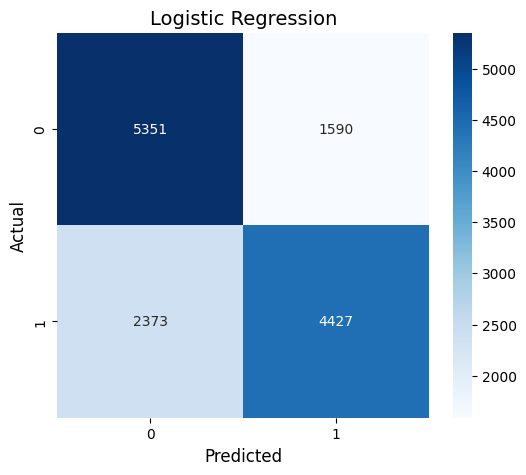

In [ ]:
# ======================================================
# Logistic Regression (FIXED train–test split)
# ======================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------
# Standardize features (FIT on TRAIN only)
# ------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ------------------------------------------------------
# Logistic Regression model
# ------------------------------------------------------
logreg = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='saga',
    random_state=42
)

# ------------------------------------------------------
# Train on TRAINING data ONLY
# ------------------------------------------------------
logreg.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# FINAL evaluation on TEST set
# ------------------------------------------------------
y_test_pred = logreg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy:.6f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# ------------------------------------------------------
# Confusion Matrix (TEST SET ONLY)
# ------------------------------------------------------
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Logistic Regression', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


Logistic Regression with 0, 7, 123 and 2024 seed value

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------------------
# Feature scaling (FIT on TRAIN only)
# ------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ------------------------------------------------------
# Seeds for robustness analysis
# ------------------------------------------------------
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    print("\n===================================")
    print(f" Logistic Regression — Seed {seed}")
    print("===================================")

    # --------------------------------------------------
    # Logistic Regression model (seed applied)
    # --------------------------------------------------
    logreg = LogisticRegression(
        max_iter=1000,
        penalty='l1',
        solver='saga',
        random_state=seed
    )

    # --------------------------------------------------
    # Train on TRAINING data only
    # --------------------------------------------------
    logreg.fit(X_train_scaled, y_train)

    # --------------------------------------------------
    # Final evaluation on TEST set
    # --------------------------------------------------
    y_test_pred = logreg.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_lr = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\nLogistic Regression – Seed Stability Results")
print(df_lr)

print("\nSummary Statistics:")
print(df_lr.describe())



 Logistic Regression — Seed 0

Seed 0 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      6941
           1       0.74      0.65      0.69      6800

    accuracy                           0.71     13741
   macro avg       0.71      0.71      0.71     13741
weighted avg       0.71      0.71      0.71     13741


 Logistic Regression — Seed 7

Seed 7 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      6941
           1       0.74      0.65      0.69      6800

    accuracy                           0.71     13741
   macro avg       0.71      0.71      0.71     13741
weighted avg       0.71      0.71      0.71     13741


 Logistic Regression — Seed 123

Seed 123 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      6941
        

**XGboost**

Test Accuracy: 0.711375

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.72      6941
           1       0.73      0.67      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.71      0.71      0.71     13741
weighted avg       0.71      0.71      0.71     13741



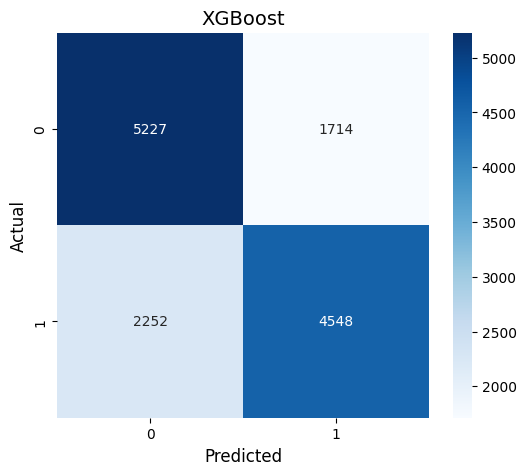

In [ ]:
# ======================================================
# XGBoost (FIXED train–test split, SAME settings)
# ======================================================

import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------
# XGBoost model
# ------------------------------------------------------
xg_model = xgb.XGBClassifier(
    max_depth=3,
    learning_rate=0.001,
    n_estimators=300,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------
# Train on TRAINING data ONLY
# ------------------------------------------------------
xg_model.fit(X_train, y_train)

# ------------------------------------------------------
# FINAL evaluation on TEST set
# ------------------------------------------------------
y_test_pred = xg_model.predict(X_test)

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Test Accuracy: {acc:.6f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# ------------------------------------------------------
# Confusion Matrix (TEST SET ONLY)
# ------------------------------------------------------
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('XGBoost', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


XGboost with seed value 0, 7, 123 and 2024

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------------------
# Seeds for robustness analysis
# ------------------------------------------------------
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    print("\n===================================")
    print(f" XGBoost — Seed {seed}")
    print("===================================")

    # --------------------------------------------------
    # XGBoost model (seed applied)
    # --------------------------------------------------
    xg_model = xgb.XGBClassifier(
        max_depth=3,
        learning_rate=0.001,
        n_estimators=300,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=seed,
        n_jobs=-1
    )

    # --------------------------------------------------
    # Train on TRAINING data ONLY
    # --------------------------------------------------
    xg_model.fit(X_train, y_train)

    # --------------------------------------------------
    # Final evaluation on TEST set
    # --------------------------------------------------
    y_test_pred = xg_model.predict(X_test)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_xgb = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print("\nXGBoost – Seed Stability Results")
print(df_xgb)

print("\nSummary Statistics:")
print(df_xgb.describe())



 XGBoost — Seed 0

Seed 0 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.72      6941
           1       0.73      0.67      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.71      0.71      0.71     13741
weighted avg       0.71      0.71      0.71     13741


 XGBoost — Seed 7

Seed 7 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.72      6941
           1       0.73      0.67      0.70      6800

    accuracy                           0.71     13741
   macro avg       0.71      0.71      0.71     13741
weighted avg       0.71      0.71      0.71     13741


 XGBoost — Seed 123

Seed 123 – Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.75      0.72      6941
           1       0.73      0.67      0.70 

# **95% CI for top models using 0, 7, 42, 123 and 2024 seed value**

In [25]:
import pandas as pd
import numpy as np
from scipy import stats

# =========================================
# Helper function to compute 95% CI
# =========================================
def compute_ci(series, confidence=0.95):
    mean = series.mean()
    std = series.std(ddof=1)
    n = series.count()

    if n > 1:
        h = stats.t.ppf((1 + confidence) / 2, n - 1) * std / np.sqrt(n)
    else:
        h = 0.0

    return mean, std, mean - h, mean + h


In [ ]:
# =========================================
# Collect all model result DataFrames
# =========================================
model_results = {
    "Decision Tree": df_dt,
    "Logistic Regression": df_lr,
    "XGBoost": df_xgb,
    "Stacking": df_stack,
    "Neural Network": df_nn,
    "CNN": df_cnn
}


In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]

summary_rows = []

# =========================================
# Build CI table
# =========================================
for model_name, df_model in model_results.items():
    row = {"Model": model_name}

    for metric in metrics:
        mean, std, ci_low, ci_high = compute_ci(df_model[metric])

        row[f"{metric}_Mean"] = mean
        row[f"{metric}_SD"] = std
        row[f"{metric}_CI_Lower"] = ci_low
        row[f"{metric}_CI_Upper"] = ci_high

    summary_rows.append(row)

# =========================================
# Final CI table
# =========================================
df_ci = pd.DataFrame(summary_rows)

pd.set_option("display.precision", 4)
print("\n================ 95% CI SUMMARY TABLE ================")
print(df_ci)



================ 95% CI SUMMARY TABLE ================
                 Model  Accuracy_Mean  Accuracy_SD  Accuracy_CI_Lower  \
0        Decision Tree         0.7143       0.0000             0.7143   
1  Logistic Regression         0.7116       0.0000             0.7116   
2              XGBoost         0.7114       0.0000             0.7114   
3             Stacking         0.7150       0.0002             0.7147   
4       Neural Network         0.7174       0.0020             0.7142   
5                  CNN         0.5915       0.0004             0.5909   

   Accuracy_CI_Upper  Precision_Mean  Precision_SD  Precision_CI_Lower  \
0             0.7143          0.7270        0.0000              0.7270   
1             0.7116          0.7357        0.0000              0.7357   
2             0.7114          0.7263        0.0000              0.7263   
3             0.7153          0.7279        0.0005              0.7271   
4             0.7205          0.7352        0.0184            

In [28]:
model_results = {
    "Random Forest": df_rf,
}
metrics = ["Accuracy", "Precision", "Recall", "F1"]

summary_rows = []

# =========================================
# Build CI table
# =========================================
for model_name, df_model in model_results.items():
    row = {"Model": model_name}

    for metric in metrics:
        mean, std, ci_low, ci_high = compute_ci(df_model[metric])

        row[f"{metric}_Mean"] = mean
        row[f"{metric}_SD"] = std
        row[f"{metric}_CI_Lower"] = ci_low
        row[f"{metric}_CI_Upper"] = ci_high

    summary_rows.append(row)

# =========================================
# Final CI table
# =========================================
df_ci = pd.DataFrame(summary_rows)

pd.set_option("display.precision", 4)
print("\n================ 95% CI SUMMARY TABLE ================")
print(df_ci)



================ 95% CI SUMMARY TABLE ================
           Model  Accuracy_Mean  Accuracy_SD  Accuracy_CI_Lower  \
0  Random Forest         0.7005       0.0043             0.6936   

   Accuracy_CI_Upper  Precision_Mean  Precision_SD  Precision_CI_Lower  \
0             0.7073          0.7279        0.0034              0.7224   

   Precision_CI_Upper  Recall_Mean  Recall_SD  Recall_CI_Lower  \
0              0.7333       0.6306     0.0204           0.5982   

   Recall_CI_Upper  F1_Mean   F1_SD  F1_CI_Lower  F1_CI_Upper  
0            0.663   0.6756  0.0102       0.6593       0.6918  


**Stacking** achieved the best overall performance while also demonstrating high robustness. It exhibited the highest mean accuracy across random seeds, accompanied by a very small standard deviation and a narrow 95% confidence interval. This indicates that the stacking ensemble not only performs well but also remains stable under different random initializations, which is consistent with the expected behavior of ensemble learning methods.

# **McNemar Tests**

In [ ]:
# =================================================
# Generate & store TEST predictions for McNemar
# =================================================

# Decision Tree (best estimator from GridSearch)
y_pred_dt = best_dt.predict(X_test)

# Logistic Regression
y_pred_logreg = logreg.predict(X_test_scaled)

# XGBoost
y_pred_xgb = xg_model.predict(X_test)

# Stacking
y_pred_stack = stacking_classifier.predict(X_test)

# Feedforward NN
y_pred_nn = np.argmax(model_simple.predict(x_test), axis=1)

# CNN
y_pred_cnn = (model_cnn.predict(X_test_cnn) >= 0.5).astype(int).ravel()


430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

# =================================================
# Test-set ground truth
# =================================================
y_true = y_test.values if hasattr(y_test, "values") else y_test

# =================================================
# Store TEST-SET predictions
# (must be from the SAME test set)
# =================================================
predictions = {
    "Decision Tree": y_pred_dt,
    "Logistic Regression": y_pred_logreg,
    "XGBoost": y_pred_xgb,
    "Stacking": y_pred_stack,
    "Feedforward NN": y_pred_nn,
    "CNN": y_pred_cnn
}

# =================================================
# McNemar test function
# =================================================
def run_mcnemar(y_true, y_pred_a, y_pred_b):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred_a = pd.Series(y_pred_a).reset_index(drop=True)
    y_pred_b = pd.Series(y_pred_b).reset_index(drop=True)

    # Discordant pairs
    b = ((y_pred_a == y_true) & (y_pred_b != y_true)).sum()
    c = ((y_pred_a != y_true) & (y_pred_b == y_true)).sum()

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=False, correction=True)
    return b, c, result.statistic, result.pvalue

# =================================================
# Run pairwise McNemar tests
# (Stacking as reference model)
# =================================================
reference_model = "Stacking"
results = []

for model_name, y_pred in predictions.items():
    if model_name == reference_model:
        continue

    b, c, chi2, p = run_mcnemar(
        y_true,
        predictions[reference_model],
        y_pred
    )

    results.append([
        reference_model,
        model_name,
        b,
        c,
        chi2,
        p
    ])

# =================================================
# Results table
# =================================================
df_mcnemar = pd.DataFrame(
    results,
    columns=[
        "Model_A",
        "Model_B",
        "A_correct_B_wrong (b)",
        "A_wrong_B_correct (c)",
        "Chi_square",
        "p_value"
    ]
)

pd.set_option("display.precision", 6)

print("\n================ McNemar Test Results ================")
print(df_mcnemar)



================ McNemar Test Results ================
    Model_A              Model_B  A_correct_B_wrong (b)  \
0  Stacking        Decision Tree                    451   
1  Stacking  Logistic Regression                    531   
2  Stacking              XGBoost                    597   
3  Stacking       Feedforward NN                    402   
4  Stacking                  CNN                   3167   

   A_wrong_B_correct (c)  Chi_square        p_value  
0                    441    0.090807   7.631535e-01  
1                    484    2.084729   1.487786e-01  
2                    547    2.098776   1.474171e-01  
3                    425    0.585248   4.442626e-01  
4                   1482  609.992687  1.122897e-134  


**Results – Statistical Significance**

McNemar’s test was conducted to assess the statistical significance of performance differences between the stacking model and other classifiers on the test set. The results indicate that stacking does not significantly outperform Decision Tree, Logistic Regression, XGBoost, or the feedforward neural network (p > 0.05), suggesting comparable predictive behavior. However, stacking significantly outperforms the CNN model (p ≪ 0.001), demonstrating a clear and statistically robust improvement.

**Tabnet**

In [ ]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00


epoch 0  | loss: 0.80896 | val_0_accuracy: 0.66739 |  0:00:15s
epoch 10 | loss: 0.56612 | val_0_accuracy: 0.71789 |  0:01:54s

Early stopping occurred at epoch 18 with best_epoch = 8 and best_val_0_accuracy = 0.72216
TabNet Test Accuracy: 0.715814

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      6941
           1       0.73      0.68      0.70      6800

    accuracy                           0.72     13741
   macro avg       0.72      0.72      0.72     13741
weighted avg       0.72      0.72      0.72     13741



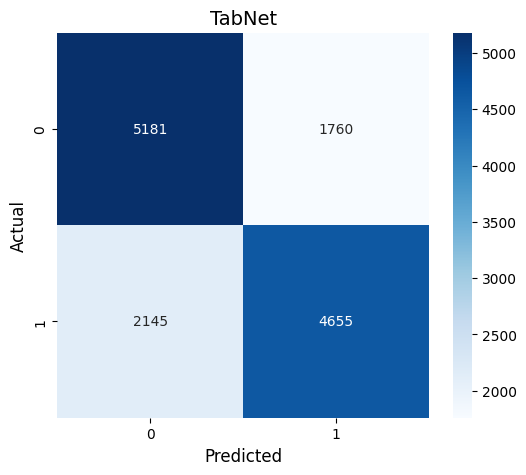

In [ ]:
# ======================================================
# TabNet (FIXED train–test split, SAME settings)
# ======================================================

import numpy as np
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Convert to numpy float32 (TabNet requirement)
# ------------------------------------------------------
X_train_tab = X_train.values.astype(np.float32)
X_test_tab  = X_test.values.astype(np.float32)
y_train_tab = y_train.values.astype(np.int64)
y_test_tab  = y_test.values.astype(np.int64)

# ------------------------------------------------------
# INTERNAL validation split (TRAIN ONLY, for early stopping)
# ------------------------------------------------------
X_tr_tab, X_val_tab, y_tr_tab, y_val_tab = train_test_split(
    X_train_tab,
    y_train_tab,
    test_size=0.2,
    random_state=42,
    stratify=y_train_tab
)

# ------------------------------------------------------
# TabNet model (UNCHANGED hyperparameters)
# ------------------------------------------------------
tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    mask_type='entmax',
    seed=42,
    verbose=10
)

# ------------------------------------------------------
# Train (validation used ONLY for early stopping)
# ------------------------------------------------------
tabnet.fit(
    X_tr_tab,
    y_tr_tab,
    eval_set=[(X_val_tab, y_val_tab)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

# ------------------------------------------------------
# FINAL evaluation on TEST set
# ------------------------------------------------------
y_pred_tab = tabnet.predict(X_test_tab)

acc = accuracy_score(y_test_tab, y_pred_tab)
print(f"TabNet Test Accuracy: {acc:.6f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_tab, y_pred_tab))

# ------------------------------------------------------
# Confusion Matrix (TEST SET ONLY)
# ------------------------------------------------------
cm_tab = confusion_matrix(y_test_tab, y_pred_tab)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tab,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("TabNet", fontsize=14)
plt.show()
